### PubMed Citation Analysis — scRNA-seq Ambient Removal Tool Adoption
Fetches per-tool GEO-filtered PubMed citation counts via the NCBI Entrez API and plots adoption trends over time. Requires per_tool_years.json (cached output from the full fetch pipeline) — if present, all API calls are skipped and the file is loaded directly. If absent, the full pipeline runs: (1) collect all papers citing Seurat/Scanpy, (2) filter for those with an associated GEO dataset entry, (3) intersect per-tool citation sets with this GEO-filtered denominator, and (4) fetch publication years. Intermediate results are written to per_tool_geo_filtered.json and per_tool_years.json. The final figure is saved as Fig_1B.png.

Cache found — loading from file.


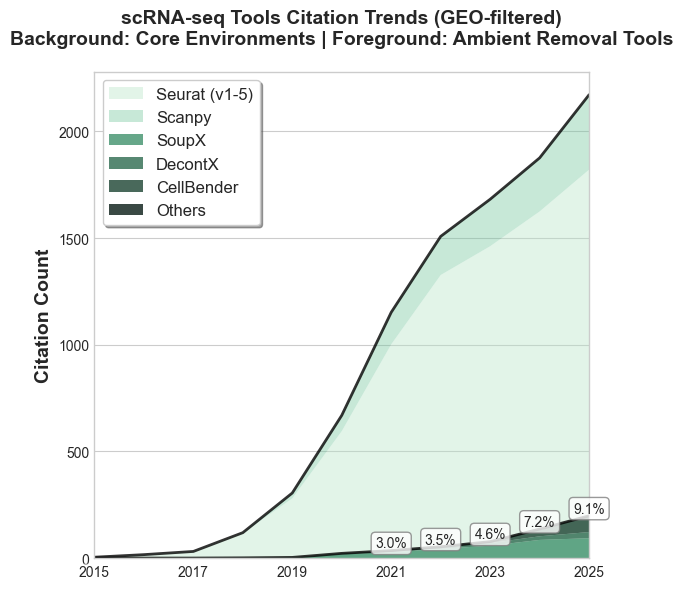

In [1]:
import json, time, os
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from Bio import Entrez

Entrez.email = "your.email@example.com"

# ── Tool definitions ──────────────────────────────────────────────────────────
tools = {
    'FastCAR':      ['38030970'],
    'scCDC':         ['38783325'],
    'Seurat (any)': ['37231261', '34062119', '31178118', '29608179', '25867923'],
    'CellBender':   ['37550580'],
    'SoupX':        ['33367645'],
    'DecontX':      ['32138770'],
    'Scanpy':       ['29409532'],
}

# ── Entrez helpers ────────────────────────────────────────────────────────────
def get_citing_papers(pmid):
    handle = Entrez.elink(dbfrom="pubmed", db="pubmed",
                          id=pmid, linkname="pubmed_pubmed_citedin")
    record = Entrez.read(handle); handle.close()
    return [link["Id"] for link in record[0]["LinkSetDb"][0]["Link"]] \
           if record[0]["LinkSetDb"] else []

def has_geo_dataset(pmid):
    try:
        handle = Entrez.elink(dbfrom="pubmed", db="gds", id=pmid, linkname="pubmed_gds")
        record = Entrez.read(handle); handle.close()
        return bool(record[0]["LinkSetDb"])
    except:
        return False

def get_publication_years(pmids, batch_size=200):
    years = {}
    for i in range(0, len(pmids), batch_size):
        batch = list(pmids)[i:i+batch_size]
        handle = Entrez.efetch(db="pubmed", id=batch, retmode="xml")
        records = Entrez.read(handle); handle.close()
        for rec in records['PubmedArticle']:
            pmid = str(rec['MedlineCitation']['PMID'])
            try:
                year = int(rec['MedlineCitation']['Article']['Journal']['JournalIssue']['PubDate']['Year'])
            except:
                try:
                    year = int(rec['MedlineCitation']['Article']['Journal']['JournalIssue']['PubDate']['MedlineDate'].split()[0])
                except:
                    year = None
            years[pmid] = year
        time.sleep(0.4)
    return years

# ── Fetch or load ─────────────────────────────────────────────────────────────
CACHE_FILE = 'per_tool_years.json'

if os.path.exists(CACHE_FILE):
    print("Cache found — loading from file.")
    with open(CACHE_FILE) as f:
        per_tool_years = json.load(f)
else:
    print("No cache — running full fetch pipeline (this will take a while).")

    # Stage 1: GEO-filtered Seurat/Scanpy citing papers
    seurat_scanpy_citing = set()
    for pmid in tools['Seurat (any)'] + tools['Scanpy']:
        seurat_scanpy_citing.update(get_citing_papers(pmid)); time.sleep(0.4)

    geo_papers_set = set()
    for i, pmid in enumerate(seurat_scanpy_citing):
        if has_geo_dataset(pmid): geo_papers_set.add(pmid)
        if (i+1) % 500 == 0: print(f"  GEO check {i+1}/{len(seurat_scanpy_citing)}")
        time.sleep(0.35)
    print(f"GEO-filtered papers: {len(geo_papers_set)}")

    # Stage 2: Per-tool GEO-filtered citing sets
    ambient_tools    = ['SoupX', 'DecontX', 'CellBender', 'FastCAR', 'scCDC']
    background_tools = ['Seurat (any)', 'Scanpy']
    per_tool_geo = {}
    for tool in ambient_tools + background_tools:
        citing = set()
        for pmid in tools[tool]:
            citing.update(get_citing_papers(pmid)); time.sleep(0.4)
        per_tool_geo[tool] = citing.intersection(geo_papers_set)
    per_tool_geo['Others'] = per_tool_geo['FastCAR'] | per_tool_geo['scCDC']
    with open('per_tool_geo_filtered.json', 'w') as f:
        json.dump({k: list(v) for k, v in per_tool_geo.items()}, f)

    # Stage 3: Publication years per tool
    per_tool_years = {}
    for tool, pmids in per_tool_geo.items():
        if tool in ['FastCAR', 'scCDC']: continue  # rolled into Others
        print(f"Fetching years for {tool}...")
        per_tool_years[tool] = get_publication_years(pmids)
    with open(CACHE_FILE, 'w') as f:
        json.dump(per_tool_years, f)
    print("Saved.")

# ── Build plot dataframe ──────────────────────────────────────────────────────
all_years = range(2015, 2026)

def years_to_counts(year_dict):
    counts = defaultdict(int)
    for pmid, year in year_dict.items():
        if year: counts[year] += 1
    return {y: counts.get(y, 0) for y in all_years}

df = pd.DataFrame({'Year': list(all_years)})
for tool in ['Seurat (any)', 'Scanpy', 'SoupX', 'DecontX', 'CellBender', 'Others']:
    df[tool] = list(years_to_counts(per_tool_years[tool]).values())

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(6, 6))

ax.stackplot(df['Year'], df['Seurat (any)'], df['Scanpy'],
             colors=['#b7e4c7', '#74c69d'], alpha=0.4, labels=['Seurat (v1-5)', 'Scanpy'])
ax.stackplot(df['Year'], df['SoupX'], df['DecontX'], df['CellBender'], df['Others'],
             colors=['#40916c', '#2d6a4f', '#1b4332', '#081c15'], alpha=0.8,
             labels=['SoupX', 'DecontX', 'CellBender', 'Others'])

bg_total  = df['Seurat (any)'] + df['Scanpy']
amb_total = df['SoupX'] + df['DecontX'] + df['CellBender'] + df['Others']
ax.plot(df['Year'], bg_total,  color='black', linewidth=2, alpha=0.8)
ax.plot(df['Year'], amb_total, color='black', linewidth=2, alpha=0.8)

# Ambient % labels
for _, row in df[df['Year'] >= 2021].iterrows():
    bg  = row['Seurat (any)'] + row['Scanpy']
    amb = row['SoupX'] + row['DecontX'] + row['CellBender'] + row['Others']
    if bg > 0:
        ax.annotate(f'{amb/bg*100:.1f}%', xy=(row['Year'], amb + 15),
                    fontsize=10, ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

# Publication milestones
milestones = [
    (2017.66, 'Scanpy\npreprint',       '#74c69d', 'black', -220, 0.4),
    (2018.5,  'SoupX\npreprint',        '#40916c', 'white', -220, 0.8),
    (2019.3,  'DecontX\npreprint',      '#2d6a4f', 'white', -220, 0.8),
    (2019.8,  'CellBender\npreprint',   '#1b4332', 'white', -220, 0.8),
    (2015.33, 'Seurat v1\npublication', '#b7e4c7', 'black', -220, 0.4),
    (2022.05, 'scAR\npreprint',         '#081c15', 'white', -220, 0.8),
    (2024.6,  'CellClear\npreprint',    '#081c15', 'white', -220, 0.8),
]
# for x, label, color, txtcolor, y_text, alpha in milestones:
#     box_x = x - 0.1 if 'DecontX' in label else (x + 0.22 if 'CellBender' in label else x)
#     ax.annotate(label, xy=(x, 1), xytext=(box_x, y_text),
#                 arrowprops=dict(arrowstyle='->', color='black', alpha=0.5, lw=1.5),
#                 fontsize=9, ha='center', va='top', color=txtcolor,
#                 bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=alpha, edgecolor='black'))

# Custom x-axis labels (hidden tick labels replaced by annotated text)
for year in range(2015, 2026, 2):
    ax.annotate(str(year), xy=(year, 0), xycoords=('data', 'axes fraction'),
                xytext=(0, -5), textcoords='offset points',
                fontsize=10, ha='center', va='top',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.6, edgecolor='none'))
ax.get_xaxis().set_visible(False)

ax.set_ylabel('Citation Count', fontsize=14, fontweight='bold')
ax.set_title('scRNA-seq Tools Citation Trends (GEO-filtered)\n'
             'Background: Core Environments | Foreground: Ambient Removal Tools',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.set_xlim(2015, 2025)

plt.tight_layout()
plt.savefig('Fig_1B.png', dpi=300)
plt.show()